In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Import datasets
data1 = pd.read_csv('data1.csv')
data2 = pd.read_csv('data2.csv')

In [12]:
data1[data1["Background"] == "Lettres"]

,UserName,Age,Background
43,Name44,22,Lettres
45,Name46,20,Lettres
48,Name49,23,Lettres
50,Name51,36,Lettres


In [4]:
x =pd.get_dummies(data1,columns=["Background"])
print(x)

   UserName  Age  Background_Economie et gestion  Background_Lettres  \
0     Name1   20                            True               False   
1     Name2   21                            True               False   
2     Name3   19                            True               False   
3     Name4   24                            True               False   
4     Name5   30                           False               False   
5     Name6   22                           False               False   
6     Name7   23                           False               False   
7     Name8   21                            True               False   
8     Name9   20                           False               False   
9    Name10   24                            True               False   
10   Name11   27                            True               False   
11   Name12   19                            True               False   
12   Name13   25                            True               F

In [6]:
f1 = x["Age"].values
f2 = x["Background_Economie et gestion"].values
f3 = x["Background_Lettres"].values
f4 = x["Background_Sciences et technologies"].values
x = np.array(list(zip(f1,f2,f3,f4)))

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x)
x=scaler.transform(x)
x

array([[0.2 , 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.7 , 0.  , 0.  , 1.  ],
       [0.3 , 0.  , 0.  , 1.  ],
       [0.35, 0.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.2 , 0.  , 0.  , 1.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.55, 1.  , 0.  , 0.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.45, 1.  , 0.  , 0.  ],
       [0.35, 0.  , 0.  , 1.  ],
       [0.25, 0.  , 0.  , 1.  ],
       [0.15, 0.  , 0.  , 1.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.55, 0.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.05, 1.  , 0.  , 0.  ],
       [0.9 , 0.  , 0.  , 1.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.3 , 0.  , 0.  , 1.  ],
       [0.95, 0.  , 0.  , 1.  ],
       [0.25, 0.  , 0.  , 1.  ],
       [0.75, 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.45, 0.  , 0.  , 1.  ],
       [0.

Text(0, 0.5, 'Inertie')

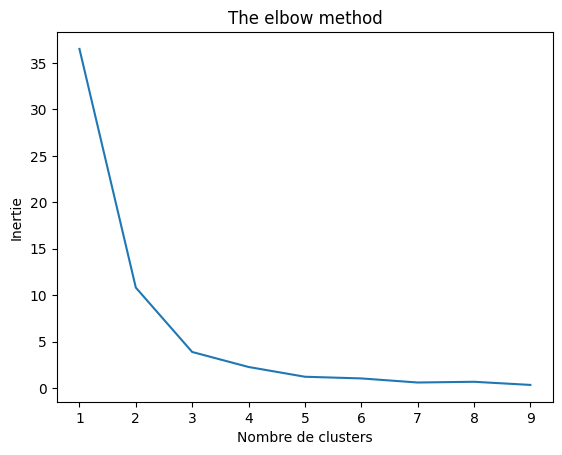

In [10]:
from sklearn.cluster import KMeans
inertia = []
for i in range (1,10):
    kmeans = KMeans(i)
    kmeans.fit(x)
    inertia_iter = kmeans.inertia_
    inertia.append(inertia_iter)

number_clusters=range(1,10)
plt.plot(number_clusters,inertia)
plt.title("The elbow method")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
kmeans.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [13]:
clusters = kmeans.predict(x)
clusters

array([1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2,
       1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 0,
       2, 0, 2, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 2], dtype=int32)

In [15]:
frame =  pd.DataFrame(x)
frame["cluster"] = clusters
frame["cluster"].value_counts()

cluster
1    28
2    26
0     4
Name: count, dtype: int64